In [1]:
import cv2
import matplotlib.pyplot as plt


#### **1. Load the normal-light photo containing a face**

In [7]:
img_color = cv2.imread('images.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)


#### **2. Load OpenCV's pre-trained Haar Cascade classifier for frontal faces**

In [8]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)
print(f"--- [TASK 8 FACE DETECTION LOG] ---")
print(f"Total faces detected: {len(faces)}")
print(f"Bounding box coordinates (x, y, w, h): {faces}")
print("-----------------------------------")

--- [TASK 8 FACE DETECTION LOG] ---
Total faces detected: 4
Bounding box coordinates (x, y, w, h): [[530 137  58  58]
 [299  95  77  77]
 [ 68 103  88  88]
 [712 131  96  96]]
-----------------------------------



#### **3. Annotate detections on image copy**

In [9]:
annotated_img = img_color.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(annotated_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(annotated_img, "Detected Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)


#### **4. Visualization: Show full detection + a zoomed crop of the facial region**

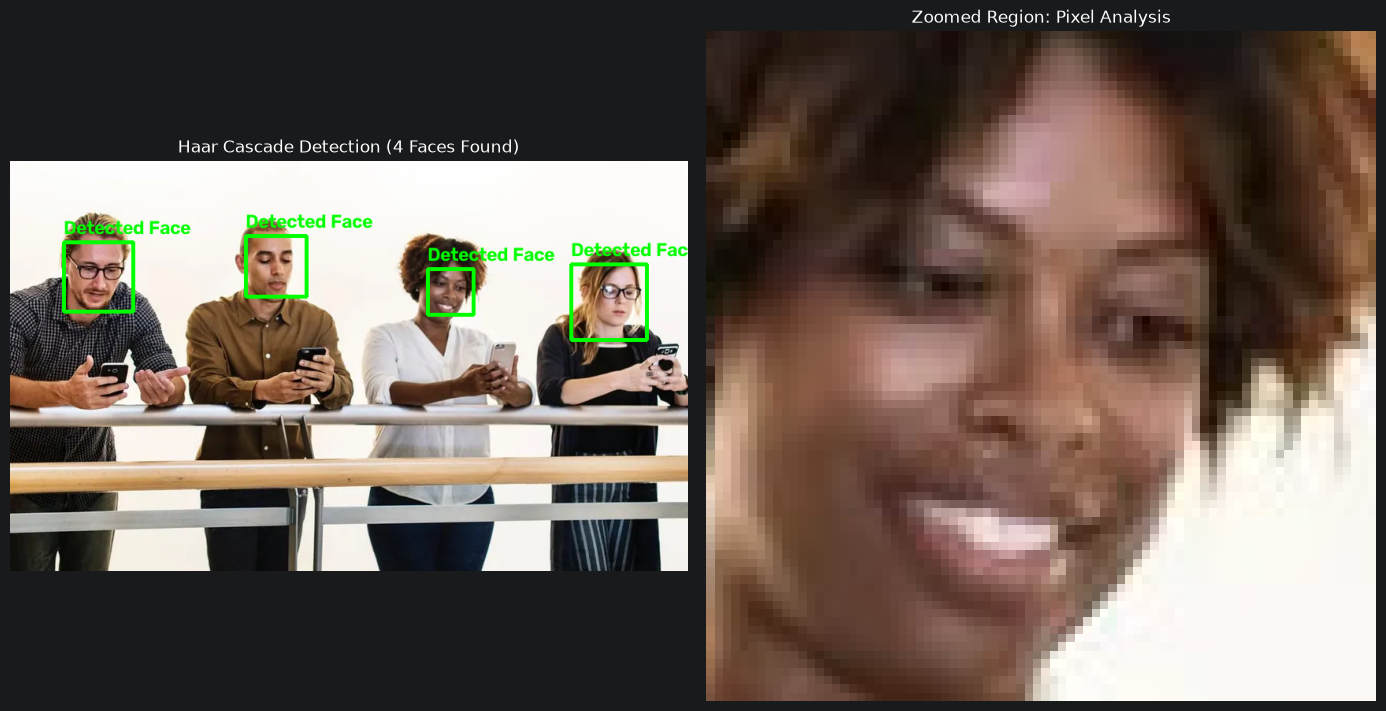

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Haar Cascade Detection ({len(faces)} Faces Found)")
axes[0].axis('off')

# If a face was found, zoom in on it; otherwise show the center frame
if len(faces) > 0:
    x, y, w, h = faces[0]
    # Add padding to zoom crop
    pad = int(0.2 * w)
    zoom_crop = img_color[max(0, y-pad):min(img_color.shape[0], y+h+pad),
                          max(0, x-pad):min(img_color.shape[1], x+w+pad)]
    axes[1].imshow(cv2.cvtColor(zoom_crop, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Zoomed Region: Pixel Analysis")
else:
    axes[1].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Missed Detection Region")
axes[1].axis('off')

plt.tight_layout()
plt.show()